
# Modelo RBC com Política Fiscal

**Autoria:** Grupo FISLAC – Banco Interamericano de Desarrollo. **Colaboração:** Ministério da Fazenda do Brasil. **Data:** Dezembro de 2025.


In [1]:
using Pkg
Pkg.add("AxisArrays")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using Pkg
using Dynare
using Serialization
using DataFrames
using XLSX
using Plots
using AxisArrays

In [3]:
mod = read("RBC_fiscal.mod", String)
println(mod)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                   Banco Interamericano de Desarrollo                    %
%                                                                         %
%                     Modelo RBC com política fiscal                      %
%                           Dezembro de 2025                              %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

%--------------------------------------------------------------------------
% 1. Definição de variáveis
%--------------------------------------------------------------------------

% Variáveis endógenas

var 
    c         (long_name='Consumo privado') 
    rk        (long_name='Retorno do capital')
    n         (long_name='Trabalho')
    k         (long_name='Capital privado') 
    x         (long_name='Investimento privado')
    y         (long_name='Produto') 
    w         (long_name='Taxa de salário') 
    rb        (long_name='Tax

In [5]:
m = @dynare("RBC_fiscal.mod");

Dynare version: 0.10.4
2026-01-02T18:04:17.508: Starting @dynare RBC_fiscal.mod
["RBC_fiscal.mod", "language=julia", "json=compute", "notmpterms"]
Dynare preprocessor version: 7.0.0+0
2026-01-02T18:04:17.528: End of preprocessing
2026-01-02T18:04:17.537: Start parse_statements!
  Steady state

──────────────────────────────────────────┬──────────
             Consumo privado              │ 0.284834
                       Retorno do capital │   0.1022
                                 Trabalho │    0.475
                          Capital privado │   2.7967
                     Investimento privado │   0.1048
                                  Produto │   0.6382
                          Taxa de salário │   0.7417
   Taxa de retorno dos ativos financeiros │   0.0494
          Produtividade Total dos Fatores │      1.0
                  Dívida bruta do governo │   0.5512
                           Receita fiscal │   0.2758
            Taxa de imposto sobre consumo │    0.162
            Tax

Starting preprocessing of the model file ...
Found 24 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Finding the optimal block decomposition of the static model...
12 block(s) found:
  10 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
Computing dynamic model derivatives (order 1).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
8 block(s) found:
  6 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.

 












2026-01-02T18:04:18.932: End parse_statements!
2026-01-02T18:04:18.932: End parser


### **1. Impostos**

**a) Simulação de um Aumento na Taxa de Imposto sobre Consumo**

In [6]:
irf_tauc = m.results.model_results[1].irfs[Symbol("Choque de imposto sobre consumo") ]

┌────┬─────────────────┬────────────────────┬──────────────┬─────────────────┬──
│    │ Consumo privado │ Retorno do capital │     Trabalho │ Capital privado │ ⋯
├────┼─────────────────┼────────────────────┼──────────────┼─────────────────┼──
│  1 │     -0.00214322 │        -4.51129e-5 │ -0.000379715 │       0.0018616 │ ⋯
│  2 │    -0.000712665 │        -6.79406e-5 │ -0.000255682 │      0.00250519 │ ⋯
│  3 │     -0.00013681 │        -7.41217e-5 │ -0.000198401 │      0.00265709 │ ⋯
│  4 │      8.93024e-5 │        -7.36821e-5 │ -0.000168901 │       0.0026146 │ ⋯
│  5 │     0.000172663 │        -7.07191e-5 │ -0.000151178 │      0.00249914 │ ⋯
│  6 │     0.000198096 │        -6.69003e-5 │ -0.000138645 │      0.00236007 │ ⋯
│  7 │      0.00020034 │        -6.28982e-5 │ -0.000128579 │      0.00221721 │ ⋯
│  8 │     0.000193603 │        -5.89774e-5 │ -0.000119841 │      0.00207832 │ ⋯
│  9 │     0.000183677 │        -5.52365e-5 │ -0.000111944 │      0.00194621 │ ⋯
│ 10 │     0.000172902 │    

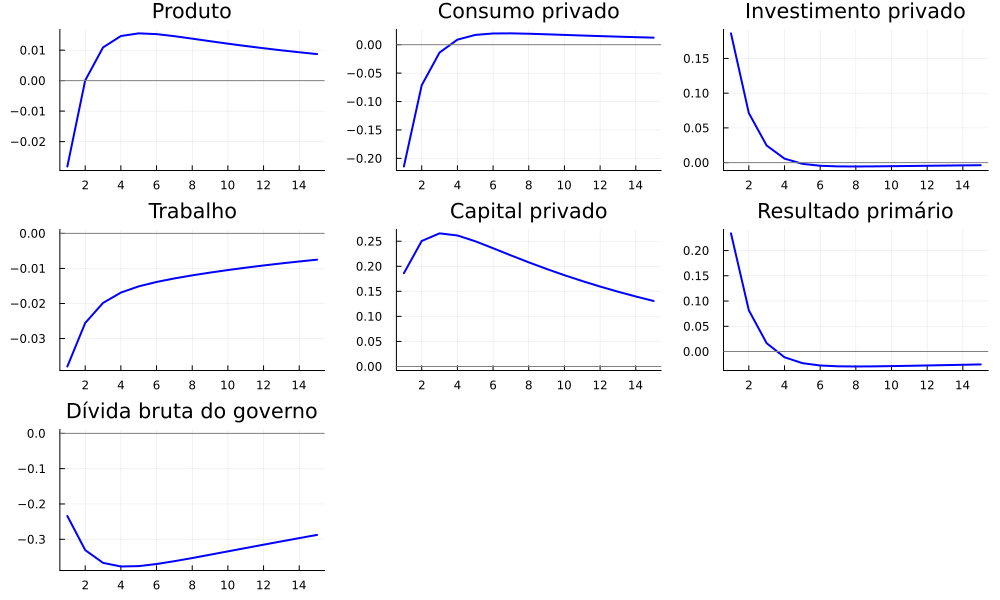

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_tauc_IRFs.png"

In [7]:
vars = [Symbol("Produto"), Symbol("Consumo privado"), Symbol("Investimento privado"), Symbol("Trabalho"), Symbol("Capital privado"), Symbol("Resultado primário"), Symbol("Dívida bruta do governo")]
titles = ["Produto", "Consumo privado", "Investimento privado", "Trabalho", "Capital privado", "Resultado primário", "Dívida bruta do governo"] 

p = plot(layout = (3, 3), size = (1000, 600))

num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_tauc[1:15, v].*100,
          color = :blue,
          lw = 2,
          title = titles[i],
          ylabel = "",
          legend = false)
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid)
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_tauc_IRFs.png")


**b) Simulação de um Aumento na Taxa de Imposto sobre a Renda do Capital**

In [8]:
irf_tauk = m.results.model_results[1].irfs[Symbol("Choque de imposto sobre a renda do capital") ]

┌────┬─────────────────┬────────────────────┬──────────────┬─────────────────┬──
│    │ Consumo privado │ Retorno do capital │     Trabalho │ Capital privado │ ⋯
├────┼─────────────────┼────────────────────┼──────────────┼─────────────────┼──
│  1 │     0.000149963 │        -2.19638e-5 │ -0.000184869 │    -0.000287076 │ ⋯
│  2 │      3.58772e-5 │        -1.38039e-6 │  -6.03756e-5 │    -0.000386325 │ ⋯
│  3 │      -9.2518e-6 │         6.56872e-6 │  -1.03244e-5 │     -0.00040975 │ ⋯
│  4 │     -2.62145e-5 │         9.36925e-6 │    9.2691e-6 │    -0.000403197 │ ⋯
│  5 │      -3.1728e-5 │         1.00883e-5 │   1.64345e-5 │    -0.000385392 │ ⋯
│  6 │       -3.264e-5 │         9.98162e-6 │   1.85602e-5 │    -0.000363946 │ ⋯
│  7 │      -3.1752e-5 │         9.56213e-6 │   1.86719e-5 │    -0.000341916 │ ⋯
│  8 │     -3.02071e-5 │         9.03856e-6 │   1.80066e-5 │    -0.000320497 │ ⋯
│  9 │     -2.84689e-5 │         8.49491e-6 │   1.70685e-5 │    -0.000300125 │ ⋯
│ 10 │     -2.67223e-5 │    

The number of labels is different than the number of variables to be plotted
The number of labels is different than the number of variables to be plotted


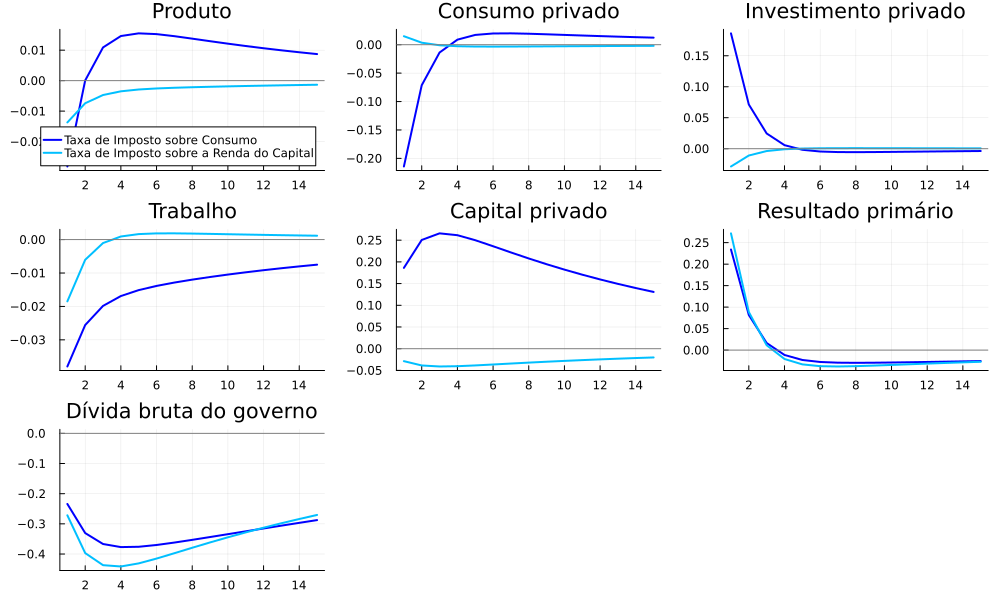

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_tauk_IRFs.png"

In [9]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_tauc[1:15, v].*100,
          color = :blue,
          lw = 2,
          label =  i == 1 ? "Taxa de Imposto sobre Consumo" : "",
          title = titles[i],
          ylabel = "")

    plot!(p[i], irf_tauk[1:15, v].*100,
          color = :deepskyblue,
          lw = 2,
          label = i == 1 ? "Taxa de Imposto sobre a Renda do Capital" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_tauk_IRFs.png")

**c) Simulação de um Aumento na Taxa de Imposto sobre Salário**

In [10]:
irf_tauw = m.results.model_results[1].irfs[Symbol("Choque de imposto sobre salário") ]

┌────┬─────────────────┬────────────────────┬──────────────┬─────────────────┬──
│    │ Consumo privado │ Retorno do capital │     Trabalho │ Capital privado │ ⋯
├────┼─────────────────┼────────────────────┼──────────────┼─────────────────┼──
│  1 │    -0.000323806 │       -0.000443368 │  -0.00373182 │       -0.002444 │ ⋯
│  2 │    -0.000350768 │       -0.000116868 │  -0.00139876 │     -0.00328894 │ ⋯
│  3 │    -0.000347809 │         1.28248e-5 │ -0.000450647 │     -0.00348837 │ ⋯
│  4 │    -0.000333483 │         6.20944e-5 │  -6.98161e-5 │     -0.00343259 │ ⋯
│  5 │     -0.00031534 │         7.86416e-5 │   7.89357e-5 │     -0.00328101 │ ⋯
│  6 │    -0.000296421 │         8.20074e-5 │   0.00013301 │     -0.00309843 │ ⋯
│  7 │    -0.000277921 │         8.01886e-5 │  0.000148711 │     -0.00291087 │ ⋯
│  8 │    -0.000260283 │         7.64498e-5 │  0.000149095 │     -0.00272853 │ ⋯
│  9 │    -0.000243646 │         7.21161e-5 │  0.000143588 │     -0.00255509 │ ⋯
│ 10 │    -0.000228023 │    

The number of labels is different than the number of variables to be plotted
The number of labels is different than the number of variables to be plotted
The number of labels is different than the number of variables to be plotted


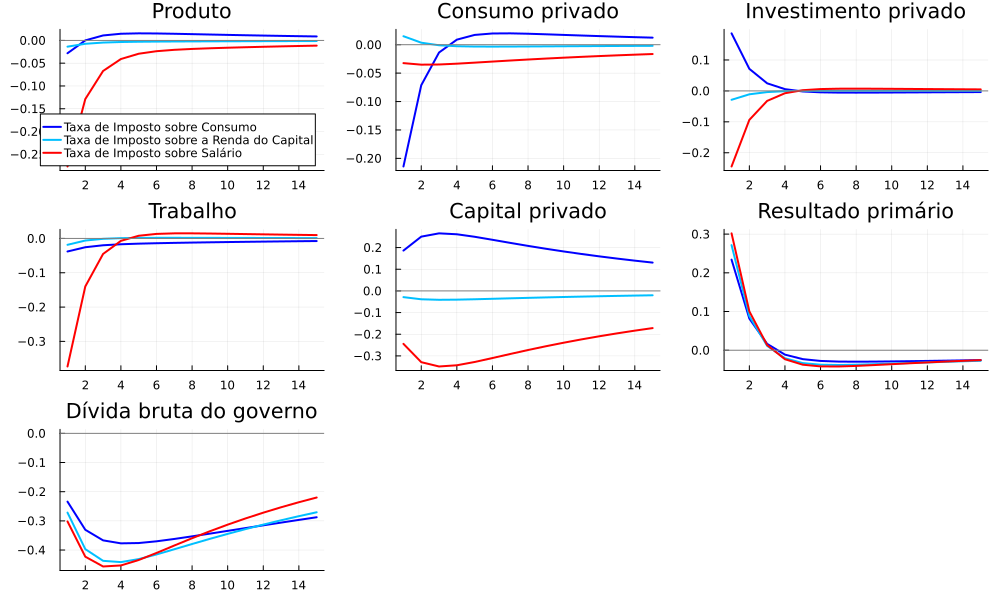

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_tauw_IRFs.png"

In [11]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_tauc[1:15, v].*100,
          color = :blue,
          lw = 2,
          label =  i == 1 ? "Taxa de Imposto sobre Consumo" : "",
          title = titles[i],
          ylabel = "")

    plot!(p[i], irf_tauk[1:15, v].*100,
          color = :deepskyblue,
          lw = 2,
          label = i == 1 ? "Taxa de Imposto sobre a Renda do Capital" : "",
          title = titles[i],
          ylabel = "")

    plot!(p[i], irf_tauw[1:15, v].*100,
          color = :red,
          lw = 2,
          label = i == 1 ? "Taxa de Imposto sobre Salário" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_tauw_IRFs.png")

### **2. Gasto Público**

**a) Simulação de um Aumento no Consumo do Governo ($\psi$ = 0)**

In [12]:
irf_cg_0 = m.results.model_results[1].irfs[Symbol("Choque no Consumo do Governo") ]

┌────┬─────────────────┬────────────────────┬─────────────┬─────────────────┬───
│    │ Consumo privado │ Retorno do capital │    Trabalho │ Capital privado │  ⋯
├────┼─────────────────┼────────────────────┼─────────────┼─────────────────┼───
│  1 │    -0.000339829 │         4.97721e-5 │ 0.000418931 │     -0.00183274 │  ⋯
│  2 │    -0.000323202 │         7.20708e-5 │ 0.000295347 │     -0.00257632 │  ⋯
│  3 │    -0.000304879 │         7.94223e-5 │ 0.000230934 │     -0.00281557 │  ⋯
│  4 │    -0.000286434 │         7.99496e-5 │ 0.000194739 │     -0.00282487 │  ⋯
│  5 │    -0.000268564 │         7.74578e-5 │ 0.000172186 │     -0.00273273 │  ⋯
│  6 │    -0.000251556 │         7.37232e-5 │ 0.000156402 │     -0.00259911 │  ⋯
│  7 │    -0.000235506 │         6.95692e-5 │ 0.000144132 │     -0.00245179 │  ⋯
│  8 │    -0.000220424 │         6.53722e-5 │ 0.000133825 │     -0.00230348 │  ⋯
│  9 │    -0.000206282 │         6.12994e-5 │ 0.000124733 │     -0.00215978 │  ⋯
│ 10 │    -0.000193035 │    

The number of labels is different than the number of variables to be plotted


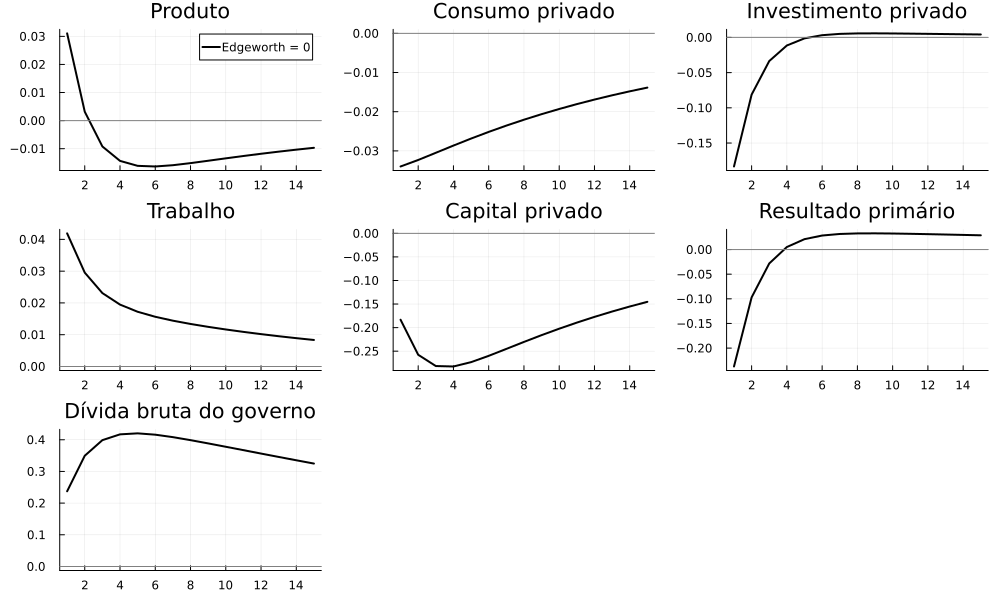

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_cg_0_IRFs.png"

In [13]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_cg_0[1:15, v].*100,
          color = :black,
          lw = 2,
          label =  i == 1 ? "Edgeworth = 0" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_cg_0_IRFs.png")

**b) Simulação de um Aumento no Consumo do Governo ($\psi$ < 0)**

In [14]:
m1 = @dynare("RBC_fiscal_psi_negativo.mod");

Dynare version: 0.10.4
2026-01-02T18:05:24.449: Starting @dynare RBC_fiscal_psi_negativo.mod
["RBC_fiscal_psi_negativo.mod", "language=julia", "json=compute", "notmpterms"]
Dynare preprocessor version: 7.0.0+0


Starting preprocessing of the model file ...


2026-01-02T18:05:24.485: End of preprocessing
2026-01-02T18:05:24.500: Start parse_statements!
  Steady state

──────────────────────────────────────────┬──────────
             Consumo privado              │ 0.544739
                       Retorno do capital │   0.1022
                                 Trabalho │   0.8077
                          Capital privado │   5.3487
                     Investimento privado │   0.2004
                                  Produto │   1.2206
                          Taxa de salário │   0.8341
   Taxa de retorno dos ativos financeiros │   0.0494
          Produtividade Total dos Fatores │      1.0
                  Dívida bruta do governo │   1.0542
                           Receita fiscal │   0.5275
            Taxa de imposto sobre consumo │    0.162
            Taxa de imposto sobre salário │     0.15
 Taxa de imposto sobre a renda do capital │     0.15
                         Imposto Lump-Sum │   0.2562
                           Gasto primári

Found 24 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Finding the optimal block decomposition of the static model...
12 block(s) found:
  10 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
Computing dynamic model derivatives (order 1).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
8 block(s) found:
  6 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.

 










  AUTOCORRELATION COEFFICIENTS

──────────────────────────────────────────┬────────────────────────────────────────
                                          │   1       2       3       4       5
───────────────────────────────────────────────────────────────────────────────────
                          Consumo privado │ 0.8473  0.7667  0.7194  0.6878  0.6635
                       Retorno do capital │ 0.8689  0.7734  0.7026   0.649  0.6073
                                 Trabalho │ 0.9555  0.9269  0.9035  0.8816  0.8599
                          Capital privado │ 0.9939  0.9805  0.9627  0.9421    0.92
                     Investimento privado │ 0.6481  0.4348  0.3012  0.2152  0.1585
                                  Produto │ 0.7939  0.6502  0.5487  0.4761  0.4234
                          Taxa de salário │ 0.9035   0.831   0.775  0.7307  0.6946
   Taxa de retorno dos ativos financeiros │ 0.9108  0.8524  0.8097  0.7755  0.7464
          Produtividade Total dos Fatores │   0.69  0.47

2026-01-02T18:05:26.033: End parse_statements!
2026-01-02T18:05:26.033: End parser


In [15]:
irf_cg_n = m1.results.model_results[1].irfs[Symbol("Choque no Consumo do Governo") ]

┌────┬─────────────────┬────────────────────┬─────────────┬─────────────────┬───
│    │ Consumo privado │ Retorno do capital │    Trabalho │ Capital privado │  ⋯
├────┼─────────────────┼────────────────────┼─────────────┼─────────────────┼───
│  1 │      0.00358479 │         7.13438e-5 │  0.00102117 │     -0.00748225 │  ⋯
│  2 │      0.00133284 │        0.000141292 │ 0.000892403 │      -0.0107874 │  ⋯
│  3 │     0.000284366 │        0.000171121 │ 0.000820227 │      -0.0121354 │  ⋯
│  4 │    -0.000198747 │        0.000182181 │ 0.000774976 │      -0.0125692 │  ⋯
│  5 │    -0.000416415 │        0.000184504 │   0.0007427 │       -0.012579 │  ⋯
│  6 │    -0.000509589 │        0.000182801 │ 0.000716833 │      -0.0123951 │  ⋯
│  7 │     -0.00054451 │        0.000179284 │ 0.000694281 │      -0.0121254 │  ⋯
│  8 │    -0.000552302 │        0.000174993 │ 0.000673581 │      -0.0118206 │  ⋯
│  9 │    -0.000547587 │        0.000170411 │ 0.000654036 │      -0.0115043 │  ⋯
│ 10 │     -0.00053723 │    

The number of labels is different than the number of variables to be plotted
The number of labels is different than the number of variables to be plotted


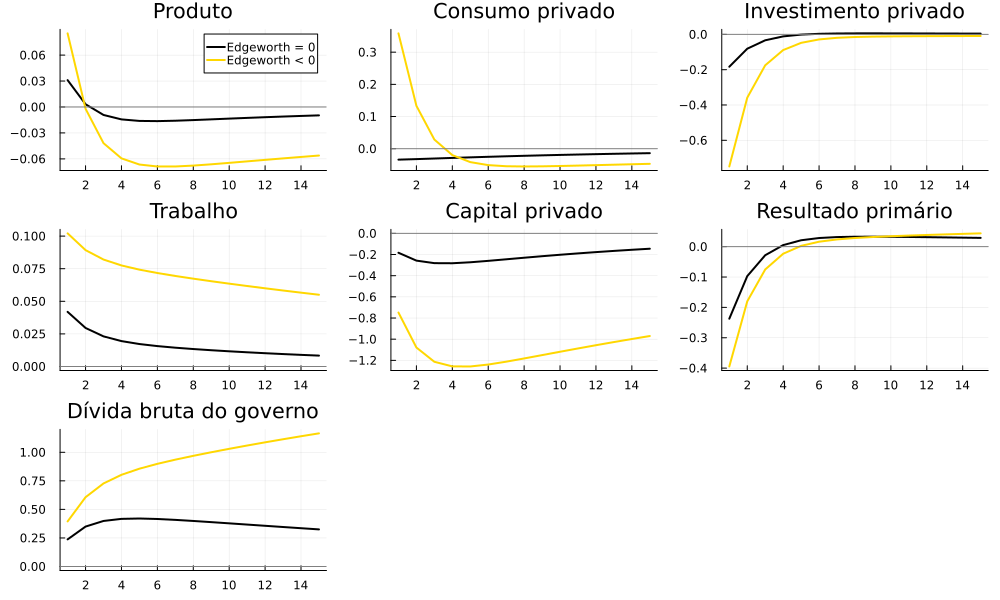

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_cg_n_IRFs.png"

In [16]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_cg_0[1:15, v].*100,
          color = :black,
          lw = 2,
          label =  i == 1 ? "Edgeworth = 0" : "",
          title = titles[i],
          ylabel = "")

    plot!(p[i], irf_cg_n[1:15, v].*100,
          color = :gold,
          lw = 2,
          label =  i == 1 ? "Edgeworth < 0" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_cg_n_IRFs.png")

**c) Simulação de um Aumento no Consumo do Governo ($\psi$ > 0)**

In [17]:
m2 = @dynare("RBC_fiscal_psi_positivo.mod");

Dynare version: 0.10.4
2026-01-02T18:05:45.338: Starting @dynare RBC_fiscal_psi_positivo.mod
["RBC_fiscal_psi_positivo.mod", "language=julia", "json=compute", "notmpterms"]
Dynare preprocessor version: 7.0.0+0
2026-01-02T18:05:45.362: End of preprocessing
2026-01-02T18:05:45.371: Start parse_statements!
  Steady state

──────────────────────────────────────────┬──────────
             Consumo privado              │ 0.186908
                       Retorno do capital │   0.1022
                                 Trabalho │   0.3364
                          Capital privado │   1.8352
                     Investimento privado │   0.0688
                                  Produto │   0.4188
                          Taxa de salário │   0.6872
   Taxa de retorno dos ativos financeiros │   0.0494
          Produtividade Total dos Fatores │      1.0
                  Dívida bruta do governo │   0.3617
                           Receita fiscal │    0.181
            Taxa de imposto sobre consumo 

Starting preprocessing of the model file ...
Found 24 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Finding the optimal block decomposition of the static model...
12 block(s) found:
  10 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
Computing dynamic model derivatives (order 1).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
8 block(s) found:
  6 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.

 












2026-01-02T18:05:46.920: End parse_statements!
2026-01-02T18:05:46.921: End parser


In [18]:
irf_cg_p = m2.results.model_results[1].irfs[Symbol("Choque no Consumo do Governo") ]

┌────┬─────────────────┬────────────────────┬────────────┬─────────────────┬────
│    │ Consumo privado │ Retorno do capital │   Trabalho │ Capital privado │ I ⋯
├────┼─────────────────┼────────────────────┼────────────┼─────────────────┼────
│  1 │     -0.00149512 │         5.05679e-6 │ 3.01449e-5 │    -0.000113694 │   ⋯
│  2 │    -0.000716053 │         6.59701e-6 │ 1.84853e-5 │    -0.000158182 │   ⋯
│  3 │     -0.00034884 │         6.98872e-6 │ 1.26654e-5 │    -0.000170846 │   ⋯
│  4 │    -0.000175282 │         6.86678e-6 │ 9.61703e-6 │    -0.000169202 │   ⋯
│  5 │     -9.28185e-5 │         6.52751e-6 │ 7.89586e-6 │    -0.000161432 │   ⋯
│  6 │     -5.32391e-5 │         6.10829e-6 │ 6.82119e-6 │    -0.000151333 │   ⋯
│  7 │       -3.388e-5 │         5.67194e-6 │ 6.07128e-6 │    -0.000140646 │   ⋯
│  8 │      -2.4084e-5 │         5.24638e-6 │ 5.49329e-6 │    -0.000130152 │   ⋯
│  9 │     -1.88376e-5 │         4.84325e-6 │ 5.01385e-6 │    -0.000120178 │   ⋯
│ 10 │       -1.578e-5 │    

The number of labels is different than the number of variables to be plotted
The number of labels is different than the number of variables to be plotted
The number of labels is different than the number of variables to be plotted


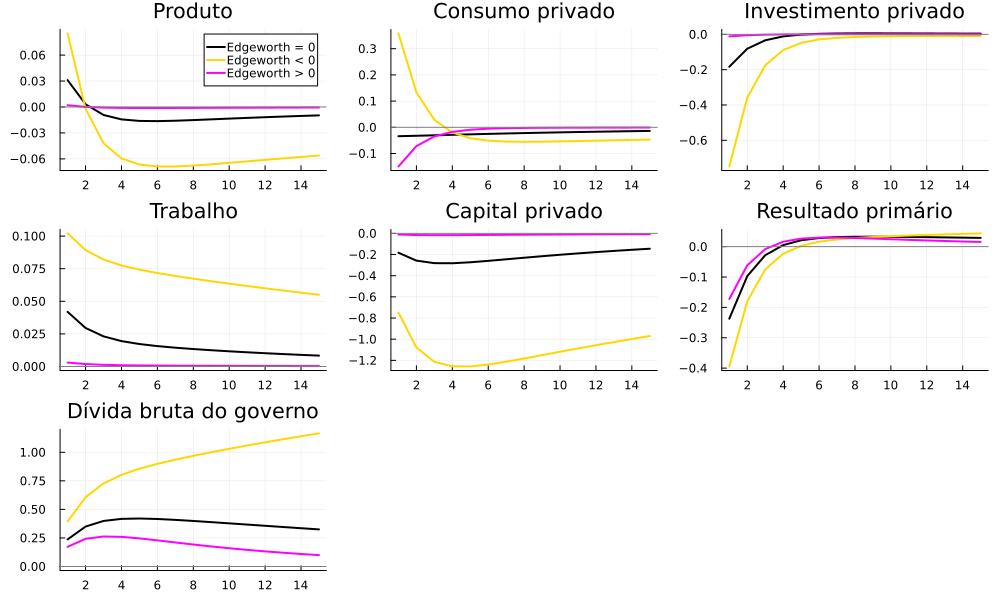

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_cg_p_IRFs.png"

In [19]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_cg_0[1:15, v].*100,
          color = :black,
          lw = 2,
          label =  i == 1 ? "Edgeworth = 0" : "",
          title = titles[i],
          ylabel = "")

    plot!(p[i], irf_cg_n[1:15, v].*100,
          color = :gold,
          lw = 2,
          label =  i == 1 ? "Edgeworth < 0" : "",
          title = titles[i],
          ylabel = "")
    plot!(p[i], irf_cg_p[1:15, v].*100,
          color = :fuchsia,
          lw = 2,
          label =  i == 1 ? "Edgeworth > 0" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_cg_p_IRFs.png")

**d) Simulação de um Aumento no Investimento Público ($\psi$ > 0)**

In [20]:
irf_xg_n = m2.results.model_results[1].irfs[Symbol("Choque de investimento público") ]

┌────┬─────────────────┬────────────────────┬─────────────┬─────────────────┬───
│    │ Consumo privado │ Retorno do capital │    Trabalho │ Capital privado │  ⋯
├────┼─────────────────┼────────────────────┼─────────────┼─────────────────┼───
│  1 │      1.12175e-5 │         4.05773e-6 │  1.35321e-6 │      3.72961e-6 │  ⋯
│  2 │      1.29222e-5 │          6.3095e-6 │  5.58303e-6 │       1.6578e-5 │  ⋯
│  3 │      1.47556e-5 │         6.78582e-6 │  6.95906e-6 │      3.24121e-5 │  ⋯
│  4 │      1.65069e-5 │         6.48232e-6 │  7.05032e-6 │      4.84677e-5 │  ⋯
│  5 │      1.80908e-5 │         5.86231e-6 │  6.58949e-6 │      6.35541e-5 │  ⋯
│  6 │      1.94793e-5 │         5.13928e-6 │  5.91655e-6 │      7.72108e-5 │  ⋯
│  7 │      2.06707e-5 │         4.40969e-6 │  5.18728e-6 │      8.93125e-5 │  ⋯
│  8 │      2.16745e-5 │         3.71525e-6 │   4.4712e-6 │      9.98834e-5 │  ⋯
│  9 │      2.25045e-5 │         3.07231e-6 │   3.7976e-6 │     0.000109011 │  ⋯
│ 10 │      2.31761e-5 │    

The number of labels is different than the number of variables to be plotted


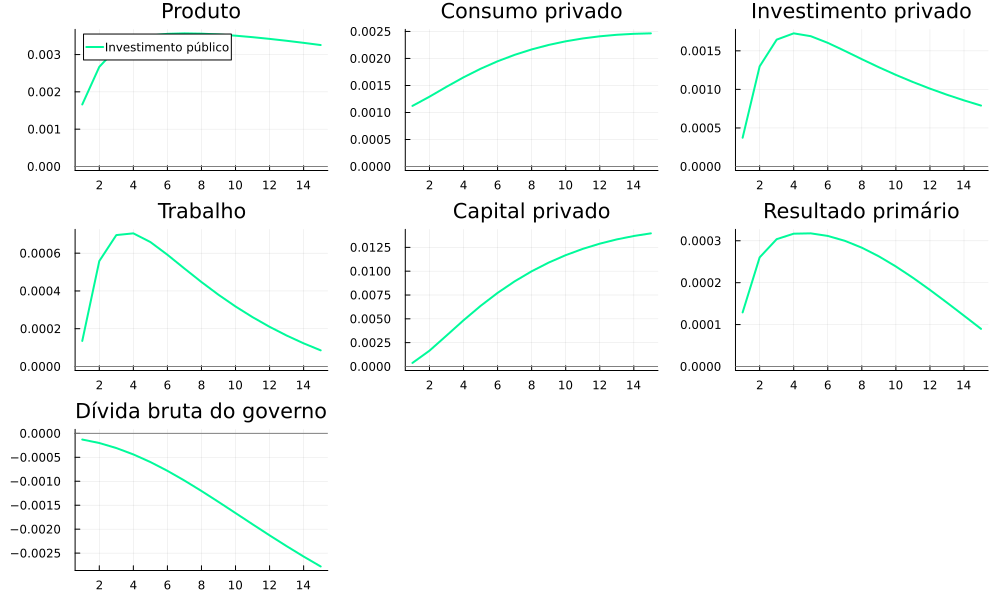

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_xg_n_IRFs.png"

In [21]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_xg_n[1:15, v].*100,
          color = :mediumspringgreen,
          lw = 2,
          label =  i == 1 ? "Investimento público" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_xg_n_IRFs.png")

### **3) Choque Antecipado**

**a) Simulação de um Choque Antecipado**

In [22]:
result_prea = @dynare("RBC_fiscal_anunciado.mod");

Dynare version: 0.10.4
2026-01-02T18:06:13.657: Starting @dynare RBC_fiscal_anunciado.mod
["RBC_fiscal_anunciado.mod", "language=julia", "json=compute", "notmpterms"]
Dynare preprocessor version: 7.0.0+0
2026-01-02T18:06:13.681: End of preprocessing
2026-01-02T18:06:13.690: Start parse_statements!


Starting preprocessing of the model file ...
Substitution of exo lags: added 3 auxiliary variables and equations.
Found 27 equation(s).
Evaluating expressions...
Computing static model derivatives (order 1).
Normalizing the static model...
Finding the optimal block decomposition of the static model...
12 block(s) found:
  10 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
Computing dynamic model derivatives (order 1).
Normalizing the dynamic model...
Finding the optimal block decomposition of the dynamic model...
8 block(s) found:
  6 recursive block(s) and 2 simultaneous block(s).
  the largest simultaneous block has 7 equation(s)
                                 and 7 feedback variable(s).
JSON written after Computing step.
Preprocessing completed.

 


  Steady state

──────────────────────────────────────────┬──────────
             Consumo privado              │ 0.284834
                       Retorno do capital │   0.1022
                                 Trabalho │    0.475
                          Capital privado │   2.7967
                     Investimento privado │   0.1048
                                  Produto │   0.6382
                          Taxa de salário │   0.7417
   Taxa de retorno dos ativos financeiros │   0.0494
          Produtividade Total dos Fatores │      1.0
                  Dívida bruta do governo │   0.5512
                           Receita fiscal │   0.2758
            Taxa de imposto sobre consumo │    0.162
            Taxa de imposto sobre salário │     0.15
 Taxa de imposto sobre a renda do capital │     0.15
                         Imposto Lump-Sum │    0.134
                           Gasto primário │   0.2486
                 Consumo público corrente │   0.2483
                     Investim

  Coefficients of approximate solution function (reduced form)

──────────────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                              │ Consumo privado_t  Retorno do capital_t  Trabalho_t  Capital privado_t  Investimento privado_t  Produto_t  Taxa de salário_t  Taxa de r

In [23]:
irf_tauw_prea = result_prea.results.model_results[1].irfs[Symbol("Choque de imposto sobre salário") ]

┌────┬─────────────────┬────────────────────┬──────────────┬─────────────────┬──
│    │ Consumo privado │ Retorno do capital │     Trabalho │ Capital privado │ ⋯
├────┼─────────────────┼────────────────────┼──────────────┼─────────────────┼──
│  1 │     -0.00014318 │         2.09704e-5 │  0.000176508 │     0.000274092 │ ⋯
│  2 │    -0.000139326 │         1.67069e-5 │  0.000187173 │     0.000569991 │ ⋯
│  3 │    -0.000136488 │          1.2298e-5 │  0.000200319 │     0.000891966 │ ⋯
│  4 │    -0.000244241 │       -0.000467058 │  -0.00377973 │     -0.00160937 │ ⋯
│  5 │    -0.000276318 │       -0.000139036 │  -0.00144359 │     -0.00250796 │ ⋯
│  6 │    -0.000278144 │         -7.9182e-6 │ -0.000492599 │     -0.00275759 │ ⋯
│  7 │    -0.000268297 │         4.26847e-5 │ -0.000109071 │     -0.00274878 │ ⋯
│  8 │    -0.000254344 │         6.04795e-5 │   4.22037e-5 │     -0.00264115 │ ⋯
│  9 │    -0.000239345 │         6.50128e-5 │   9.86392e-5 │      -0.0024997 │ ⋯
│ 10 │    -0.000224514 │    

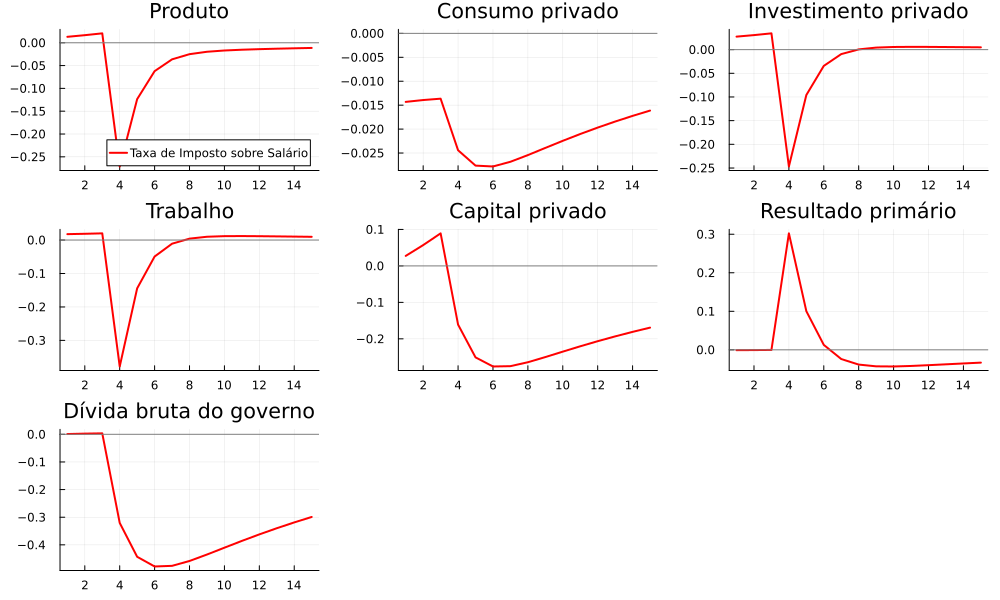

"/workspaces/julia_codespace_template/FISLAC/Sessão 4 - Política Fiscal em um Modelo RBC Canônico/Código-Material/RBC_prea_IRFs.png"

In [24]:
p = plot(layout = (3, 3), size = (1000, 600))
num_plots = length(vars)

for (i, v) in enumerate(vars)
    plot!(p[i], irf_tauw_prea[1:15, v].*100,
          color = :red,
          lw = 2,
          label =  i == 1 ? "Taxa de Imposto sobre Salário" : "",
          title = titles[i],
          ylabel = "")
    hline!(p[i], [0], color = :grey, lw = 1, linestyle = :solid, label = "")
end

total_layout = 3*3

for i in (num_plots + 1):total_layout
    plot!(p[i], framestyle = :none)
end

display(p)
savefig("RBC_prea_IRFs.png")